In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df_sales = pd.read_csv(r"C:\Users\ASUS\Desktop\Desktop\Infotact Internship\Project 1 - Omnichannel Retail Sales and Inventory\data\retail_sales_ml_apl.csv")

In [3]:
df_sales.head()

,Transaction Date,Sales Type,Is Return,Reason of Return,Supplier,Product No,Product Description,Product Division,Product Category,Product Subcategory,Product Segment,Store,Sales Channel,Qty Sold,Sales Amount,Cogs,Number of Transactions
0,2025-09-01,Full Price,0,NaN,Vendor 0169,PROD-139867,PROD-100449 SEG-500065 Scholar Footwear Trailb...,Scholar Footwear,Scholar Footwear Trailblazer,Scholar Footwear Trailblazer Equilibrium,SEG-500065 Scholar Footwear Trailblazer Equili...,STR-1006,Channel Alpha,1.0,115.00,52.31,1
1,2025-09-07,Full Price,0,NaN,Vendor 0166,PROD-100449,PROD-100825 SEG-500112 Heritage Footwear Fligh...,Femme Footwear,Femme Footwear Flight Classic,Femme Footwear Flight Classic Varied,SEG-500112 Heritage Footwear Flight Classic Ze...,STR-1198,Channel Alpha,1.0,115.00,58.47,1
2,2025-08-06,Promo,0,NaN,Vendor 0169,PROD-153623,PROD-148813 SEG-511388 Scholar Footwear Trailb...,Scholar Footwear,Scholar Footwear Trailblazer,Scholar Footwear Trailblazer Equilibrium,SEG-511388 Scholar Footwear Trailblazer Equili...,STR-1157,Channel Alpha,1.0,79.99,43.76,1
3,2025-08-31,Full Price,0,NaN,Vendor 0246,PROD-140876,PROD-100419 SEG-500063 Scholar Footwear Boot C...,Scholar Footwear,Scholar Footwear Boot Collection,Scholar Footwear Boot Collection Woodland,SEG-500063 Scholar Footwear Boot Collection Wo...,STR-1234,Channel Alpha,1.0,110.00,50.60,1
4,2026-03-22,Full Price,0,NaN,Vendor 0169,PROD-166113,PROD-149345 SEG-511444 Femme Footwear Trailbla...,Femme Footwear,Femme Footwear Trailblazer,Femme Footwear Trailblazer Equilibrium,SEG-511444 Femme Footwear Trailblazer Equilibrium,STR-1157,Channel Alpha,1.0,160.00,77.95,1


In [4]:
print(df_sales.info())
print(df_sales.describe())

<class 'pandas.DataFrame'>
RangeIndex: 125751 entries, 0 to 125750
Data columns (total 17 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   Transaction Date        125751 non-null  str    
 1   Sales Type              125751 non-null  str    
 2   Is Return               125751 non-null  int64  
 3   Reason of Return        0 non-null       float64
 4   Supplier                125751 non-null  str    
 5   Product No              125751 non-null  str    
 6   Product Description     125751 non-null  str    
 7   Product Division        125751 non-null  str    
 8   Product Category        125751 non-null  str    
 9   Product Subcategory     125751 non-null  str    
 10  Product Segment         125751 non-null  str    
 11  Store                   125751 non-null  str    
 12  Sales Channel           125751 non-null  str    
 13  Qty Sold                125751 non-null  float64
 14  Sales Amount            125751 

In [5]:
df_sales.isna().sum()

Transaction Date               0
Sales Type                     0
Is Return                      0
Reason of Return          125751
Supplier                       0
Product No                     0
Product Description            0
Product Division               0
Product Category               0
Product Subcategory            0
Product Segment                0
Store                          0
Sales Channel                  0
Qty Sold                       0
Sales Amount                   0
Cogs                           0
Number of Transactions         0
dtype: int64

In [14]:
# Transaction Date is in str format - converting it to date time obejct 
df_sales['Transaction Date'] = pd.to_datetime(df_sales['Transaction Date'])

In [7]:
for col in df_sales.columns.values:
    print(col, ":", len(df_sales[col].unique()))

Transaction Date : 326
Sales Type : 5
Is Return : 2
Reason of Return : 1
Supplier : 30
Product No : 2326
Product Description : 2313
Product Division : 3
Product Category : 27
Product Subcategory : 51
Product Segment : 600
Store : 40
Sales Channel : 1
Qty Sold : 18
Sales Amount : 996
Cogs : 4992
Number of Transactions : 14


## Univariate Analysis

In [26]:
#first and last date in the dataset
print(df_sales['Transaction Date'].min())
print(df_sales['Transaction Date'].max())

#total duration covered
start_date = df_sales['Transaction Date'].min()
end_date = df_sales['Transaction Date'].max()
duration = end_date - start_date
print(duration)

#Number of unique dates
print(df_sales['Transaction Date'].nunique())

#number of months covered
print(df_sales['Transaction Date'].dt.month.nunique())

#Extract Start and End Month-Year
print(start_date.strftime('%B %Y'))
print(end_date.strftime('%B %Y'))

2025-06-01 00:00:00
2026-04-24 00:00:00
327 days 00:00:00
326
11
June 2025
April 2026


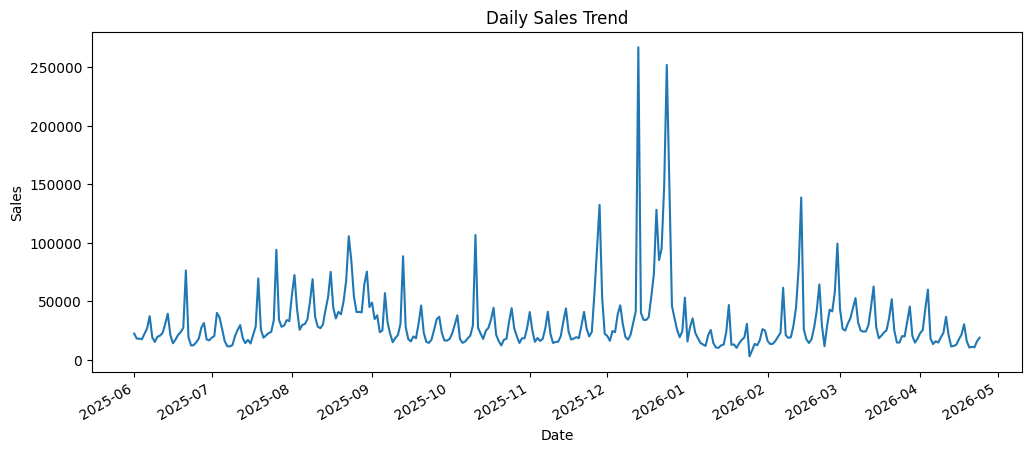

In [31]:
#daily sales
daily_sales = df_sales.groupby('Transaction Date')['Sales Amount'].sum()
daily_sales.head()

daily_sales.plot(figsize=(12,5))

plt.title("Daily Sales Trend")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.show()